In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import pickle
from datetime import datetime
from pathlib import Path

import sys
sys.path.append('../../')
from codebase.pairwise_copy_spatial_simulations import Simulate_Fish_School, Simulate_Fish_School_Excluded_Volume

from codebase.subgroup_analysis import get_num_neighbours, assign_state_variable_and_get_transitions, _generate_sum_partitions, annotate_subgroups_framewise
from codebase.parameter_fitting import fit_s_epsilon_jointly_bounded

In [3]:
fish_ages = [2,4,6,8] # weeks
bodylengths = [4,7,10,12] # mm, from Zada et. al. 2024
arena_radii = [75, 150, 150, 150] # mm, radius of experimental arena for each age group
L = 50 #mm 
optimal_omega = 0.032 # coefficient of excluded volume interaction turns

microscopic_params_full_dataset = pd.read_csv('../../Results/microscopic_params_full_dataset.csv').to_numpy()
param_distribution_data = np.load('../../Results/parameter_distribution_from_subsamples.npz')

# Run simulations with randomly sampled microscopic parameters

In [4]:
def sample_params_run_sims_and_analyze_results(N_fish=4, 
                                 Tmax=500, 
                                 dt=0.01, 
                                 N_sims=20, 
                                 N_samples=20, 
                                 param_distribution_data=param_distribution_data, 
                                 arena_radii=arena_radii, 
                                 L=L,
                                 excluded_volume=False,
                                 optimal_omega=optimal_omega,
                                 fish_ages=fish_ages, 
                                 random_state=0
                                 ):

    def sample_positive_mvn(mean, cov, N_samples, random_state):
        # Create a random number generator
        rng = np.random.default_rng(random_state)
        samples = []
        while len(samples) < N_samples:
            candidate = rng.multivariate_normal(mean, cov)
            if np.all(candidate > 0):
                samples.append(candidate)
        return np.array(samples)
    
    # enumerate system states i.e. subgroup configurations
    states_list_og = _generate_sum_partitions(N_fish)
    if N_fish == 4:
        #switch order of [2,2] and [1,3]!
        order = [0,1,3,2,4]
        states_list = [states_list_og[i] for i in order]
    else:
        states_list = states_list_og
    Nstates = len(states_list)

    frames = int(Tmax/dt) + 1
    N_ages = len(fish_ages)
    # arrays to save results
    sampled_params = np.empty((N_ages, N_samples, 4)) # s, eps, c, v
    neighbors_all_ages_and_samples = np.empty((N_ages,N_samples,N_sims, N_fish, frames))
    transition_matrices_all_ages_and_samples = np.empty((N_ages,N_samples, N_sims, Nstates, Nstates))
    sys_state_var_all_ages_and_samples = np.empty((N_ages, N_samples, N_sims, frames), dtype=int)

    for j, age in enumerate(fish_ages):

        R = arena_radii[j] #mm, radius of arena for simulation

        # sample parameters
        mean = param_distribution_data['agewise_mean'][j,:]
        cov = param_distribution_data['agewise_cov'][j,:,:]
        s_upper_bound = param_distribution_data['s_upper_bounds'][j]
        random_sample = sample_positive_mvn(mean, cov, N_samples, random_state)

        # record microscopic parameters for each sample
        sampled_params[j,:,3] = random_sample[:,3] #v
        sampled_params[j,:,2] = random_sample[:,1] #c
        # s,epsilon will be calculated below from alpha and slope for each sample

        for i in range(N_samples):
            # calculate s, epsilon for the sample
            alpha = random_sample[i,0]
            slope = random_sample[i,2]
            s, epsilon = fit_s_epsilon_jointly_bounded(alpha, slope, s_upper_bound)
            sampled_params[j,i,0] = s
            sampled_params[j,i,1] = epsilon

            for kk in range(N_sims):
                s = np.ones(N_fish)*sampled_params[j,i,0] # s^-1, rate of diffusion
                eps = np.ones(N_fish)*sampled_params[j,i,1] # variance of diffusion noise
                c = np.ones(N_fish)*sampled_params[j,i,2] # s^-1, rate of copying 
                v = np.ones(N_fish)*sampled_params[j,i,3] # mm/s, speed

                if excluded_volume:
                    sim = Simulate_Fish_School_Excluded_Volume(N=N_fish, 
                                    v=v, 
                                    R=R, 
                                    s=s, 
                                    eps=eps, 
                                    c=c, 
                                    Tmax=Tmax, 
                                    dt=dt, 
                                    L=L, 
                                    omega=optimal_omega, 
                                    R_ex = bodylengths[j], 
                                    seed=kk)
                else:
                    sim = Simulate_Fish_School(N=N_fish, 
                                    v=v, 
                                    R=R, 
                                    s=s, 
                                    eps=eps, 
                                    c=c, 
                                    Tmax=Tmax, 
                                    dt=dt, 
                                    L=L, 
                                    seed=kk)

                x,y,theta = sim.run_simulation()
                # subgroup analysis
                sys_state_var, transitions = assign_state_variable_and_get_transitions(x,y,L,states_list)
                sys_state_var_all_ages_and_samples[j,i,kk,:] = sys_state_var
                transition_matrices_all_ages_and_samples[j,i,kk,:,:] = transitions
                # interacting neighbors
                neighbors_all_ages_and_samples[j,i,kk,:,:] = get_num_neighbours(x,y,L).reshape(N_fish,-1)

            if i%10==0:
                print(f"Sample {i+1}/{N_samples} for {age}wpf completed at {datetime.now().strftime('%H:%M:%S')}")

    # save analysis results
    analysis_results_sims = {
        'sampled_parameters': sampled_params,
        'neighbours': neighbors_all_ages_and_samples,
        'sys_state_var': sys_state_var_all_ages_and_samples,
        'transition_matrix': transition_matrices_all_ages_and_samples,
        'parameter_names' : param_distribution_data['parameter_names'],
        }
        
    return analysis_results_sims


In [5]:
N_samples = 20
N_sims = 20
Tmax = 600
dt = 0.01
N_fish = 4

### Without excluded volume

In [6]:
results_path = Path('../../Results/model_sims_no_exclusion_results.pkl')
if results_path.is_file():
    with open(results_path, 'rb') as f:
        model_sims_no_exclusion_results = pickle.load(f)
else:
    model_sims_no_exclusion_results = sample_params_run_sims_and_analyze_results(N_fish=4,
                                                                           Tmax=Tmax,
                                                                            dt=dt,
                                                                            N_sims=N_sims,
                                                                            N_samples=N_samples,
                                                                            excluded_volume=False)

    # save results
    with open(results_path, 'wb') as f:
        pickle.dump(model_sims_no_exclusion_results, f)


### With excluded volume

In [7]:
results_path = Path('../../Results/model_sims_with_exclusion_results.pkl')
if results_path.is_file():
    with open(results_path, 'rb') as f:
        model_sims_with_exclusion_results = pickle.load(f)
else:
    model_sims_with_exclusion_results = sample_params_run_sims_and_analyze_results(N_fish=4,
                                                                           Tmax=Tmax,
                                                                            dt=dt,
                                                                            N_sims=N_sims,
                                                                            N_samples=N_samples,
                                                                            excluded_volume=True)

    # save results
    with open(results_path, 'wb') as f:
        pickle.dump(model_sims_with_exclusion_results, f)


### Load subgroup analysis results for data 

In [8]:
with open('../../Results/experiments_subgroup_analysis_results.pkl', 'rb') as f:
        analysis_results_data = pickle.load(f)


In [9]:
# system states 
states_list_og = _generate_sum_partitions(N_fish)
#switch order of [2,2] and [1,3]!
order = [0,1,3,2,4]
states_list = [states_list_og[i] for i in order]
Nstates = len(states_list)

/var/folders/52/3myd7xrd0fg654krp55x6_zc0000gn/T/ipykernel_2936/3748763398.py:204: UserWarning: Adding colorbar to a different Figure <Figure size 620x500 with 12 Axes> than <Figure size 20x250 with 1 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, cax=ax)


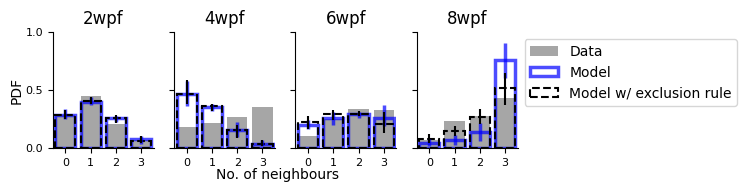

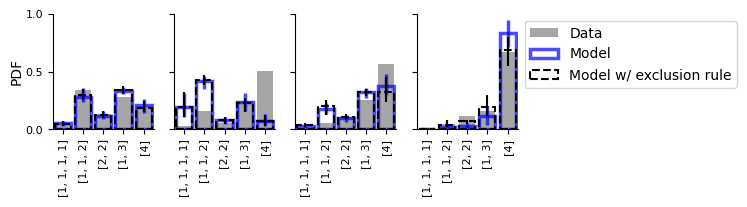

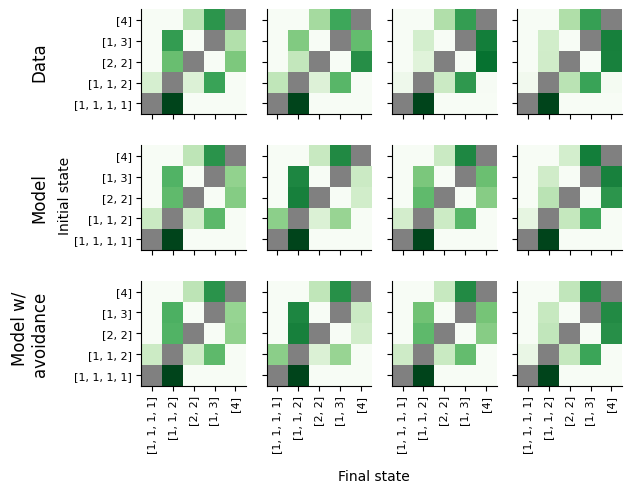

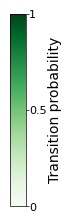

In [10]:
# plot results 

w = 8
h = 2

labelsize = 10
ticksize = 8
titlesize = 12

# separate plots for neighbors, subgroups and heatmaps
fig_n, ax_n = plt.subplots(1,4,figsize=(6,1.5))
fig_s, ax_s = plt.subplots(1,4,figsize=(6,1.5))
fig_h, ax_h = plt.subplots(3,4,figsize=(6.2,5))

for j,age in enumerate(fish_ages):
    
    # number of neighbors 
    bin_edges = -0.5 + np.arange(N_fish+1)
    bins = bin_edges[:-1] + 0.5
    # data
    ax_n[j].hist(analysis_results_data['num_neighbours'][j], bins=bin_edges, density=True, label='Data', rwidth=0.8,color='grey',alpha=0.7)
    # simulations 
    # get histogram for each sample, and plot avg,std
    binned_data = np.zeros((N_samples, len(bins)))
    binned_data_with_exclusion = np.zeros((N_samples, len(bins)))
    for i in range(N_samples):
        binned_data[i,:], _ = np.histogram(model_sims_no_exclusion_results['neighbours'][j,i,:,:,:].reshape(-1), bins=bin_edges, density=True)  
        binned_data_with_exclusion[i,:], _ = np.histogram(model_sims_with_exclusion_results['neighbours'][j,i,:,:,:].reshape(-1), bins=bin_edges, density=True)
    mean = np.mean(binned_data, axis=0)
    lower_bound = np.quantile(binned_data, 0.025, axis=0)
    upper_bound = np.quantile(binned_data, 0.975, axis=0)
    ax_n[j].bar(bins, mean, facecolor='none', edgecolor='b', alpha=0.7, linewidth=2.5, width=0.8, label='Model')
    ax_n[j].errorbar(bins, mean, yerr=[mean-lower_bound, upper_bound-mean], fmt='none', ecolor='b', elinewidth=2.5, capsize=0, alpha=0.7)
    mean = np.mean(binned_data_with_exclusion, axis=0)
    lower_bound = np.quantile(binned_data_with_exclusion, 0.025, axis=0)
    upper_bound = np.quantile(binned_data_with_exclusion, 0.975, axis=0)
    ax_n[j].bar(bins, mean, facecolor='none', edgecolor='k', alpha=1, linewidth=1.5, width=0.8, linestyle="--", label='Model w/ exclusion rule')
    ax_n[j].errorbar(bins, mean, yerr=[mean-lower_bound, upper_bound-mean], fmt='none', ecolor='k', linestyle='--', elinewidth=1.5, capsize=0)
    ax_n[j].set_title(f"{age}wpf", fontsize=titlesize)
    #ax_n[j].set_xlabel("No. of neighbours", fontsize=labelsize, labelpad=1)
    ax_n[j].set_xlim([-0.5,N_fish-0.5])
    ax_n[j].set_xticks(np.arange(0,N_fish,1))
    ax_n[j].set_ylim([0,1])
    ax_n[j].set_yticks([0,0.5,1])
    ax_n[j].tick_params(axis='both', which='major', labelsize=ticksize)
    if j==0:
        ax_n[j].set_ylabel("PDF", fontsize=labelsize, labelpad=1)
    else:
        ax_n[j].set_yticklabels([])
    ax_n[j].spines['top'].set_visible(False)
    ax_n[j].spines['right'].set_visible(False)

    # system state
    bin_edges =np.arange(-0.5,Nstates+0.5,1)
    bins = bin_edges[:-1] + 0.5
    # data
    sys_state_var = analysis_results_data['sys_state_var'][j]
    ax_s[j].hist(sys_state_var, bins=bin_edges, density=True, label='Data', rwidth=0.8,color='grey',alpha=0.7)
    # simulations 
    # get histogram for each sample, and plot avg,std
    binned_data = np.zeros((N_samples, len(bins)))
    binned_data_with_exclusion = np.zeros((N_samples, len(bins)))
    for i in range(N_samples):
        binned_data[i,:], _ = np.histogram(model_sims_no_exclusion_results['sys_state_var'][j,i,:,:].reshape(-1), bins=bin_edges, density=True)
        binned_data_with_exclusion[i,:], _ = np.histogram(model_sims_with_exclusion_results['sys_state_var'][j,i,:,:].reshape(-1), bins=bin_edges, density=True)
    mean = np.mean(binned_data, axis=0)
    lower_bound = np.quantile(binned_data, 0.025, axis=0)
    upper_bound = np.quantile(binned_data, 0.975, axis=0)
    ax_s[j].bar(bins, mean, facecolor='none', edgecolor='b', alpha=0.7, linewidth=2.5, width=0.8, label='Model')
    ax_s[j].errorbar(bins, mean, yerr=[mean-lower_bound, upper_bound-mean], fmt='none', ecolor='b', elinewidth=2.5, capsize=0, alpha=0.7)
    mean = np.mean(binned_data_with_exclusion, axis=0)
    lower_bound = np.quantile(binned_data_with_exclusion, 0.025, axis=0)
    upper_bound = np.quantile(binned_data_with_exclusion, 0.975, axis=0)
    ax_s[j].bar(bins, mean, facecolor='none', edgecolor='k', alpha=1, linewidth=1.5, width=0.8, linestyle="--", label='Model w/ exclusion rule')
    ax_s[j].errorbar(bins, mean, yerr=[mean-lower_bound, upper_bound-mean], fmt='none', ecolor='k', linestyle='--', elinewidth=1.5, capsize=0)
    #ax[1,j].set_title(f"{age} weeks", fontsize=14)
    ax_s[j].set_xlim([-0.5,Nstates-0.5])
    ticks = [f"{states_list[n]}" for n in range(Nstates)]
    ax_s[j].set_xticks(np.arange(0,Nstates,1), ticks, rotation=90, fontsize=ticksize)
    ax_s[j].set_ylim([0,1])
    ax_s[j].set_yticks([0,0.5,1])
    ax_s[j].tick_params(axis='y', which='major', labelsize=ticksize)
    if j==0:
        ax_s[j].set_ylabel("PDF", fontsize=labelsize, labelpad=1)
    else:
        ax_s[j].set_yticklabels([])

    ax_s[j].spines['top'].set_visible(False)
    ax_s[j].spines['right'].set_visible(False)

    # transition matrix (data)
    mat = np.copy(analysis_results_data['sys_state_transitions'][j])
    for mm in range(Nstates):
        mat[mm,mm] = np.nan
    #normalize by total number of transitions of each state
    mat = mat/ np.tile(np.nansum(mat,axis=1).reshape(-1,1),(1,Nstates))
    im=ax_h[0,j].imshow(mat,origin='lower',cmap='Greens', vmin=0, vmax=1)
    ax_h[0,j].set_facecolor((0.5,0.5,0.5))
    ax_h[0,j].set_xlim([-0.5,Nstates-0.5])
    ax_h[0,j].set_ylim([-0.5,Nstates-0.5])
    ax_h[0,j].set_xticks(np.arange(Nstates),[])
    ax_h[0,j].set_yticks(np.arange(Nstates),[])
    #ax[2,j].set_title("Data", fontsize=14)
    if j==0 :
        #ax_h[0,j].set_ylabel("Initial state", fontsize=labelsize, labelpad=1)
        ax_h[0,j].set_yticklabels(ticks, fontsize=ticksize)
    ax_h[0,j].spines['top'].set_visible(False)
    ax_h[0,j].spines['right'].set_visible(False)

    # transition matrix (simulations, mean over samples)
    N_samples = model_sims_no_exclusion_results['transition_matrix'].shape[1]
    mat_per_sample = np.zeros((N_samples,Nstates,Nstates))
    for i in range(N_samples):
        mat= np.sum(model_sims_no_exclusion_results['transition_matrix'][j,i,:,:,:],axis=0)
        for mm in range(Nstates):
            mat[mm,mm] = np.nan
        #normalize by total number of transitions of each state
        mat = mat/ np.tile(np.nansum(mat,axis=1).reshape(-1,1),(1,Nstates))
        mat_per_sample[i,:,:] = mat
    mean_mat = np.mean(mat_per_sample, axis=0)
    lower_bound_mat = np.quantile(mat_per_sample, 0.025, axis=0)
    upper_bound_mat = np.quantile(mat_per_sample, 0.975, axis=0)
    im=ax_h[1,j].imshow(mean_mat,origin='lower',cmap='Greens', vmin=0, vmax=1)
    ax_h[1,j].set_facecolor((0.5,0.5,0.5))
    ax_h[1,j].set_xlim([-0.5,Nstates-0.5])
    ax_h[1,j].set_ylim([-0.5,Nstates-0.5])
    ax_h[1,j].set_xticks(np.arange(Nstates),[])
    ax_h[1,j].set_yticks(np.arange(Nstates),[])
    #ax[3,j].set_title("Simulations", fontsize=14)
    #ax[3,j].set_xlabel("Final state", fontsize=12)
    if j==0 :
       # ax_h[1,j].set_ylabel("Initial state", fontsize=labelsize, labelpad=1)
        ax_h[1,j].set_yticklabels(ticks, fontsize=ticksize)
    ax_h[1,j].spines['top'].set_visible(False)
    ax_h[1,j].spines['right'].set_visible(False)

    # transition matrix (simulations with exclusion rule, mean over samples)
    N_samples = model_sims_with_exclusion_results['transition_matrix'].shape[1]
    mat_per_sample = np.zeros((N_samples,Nstates,Nstates))
    for i in range(N_samples):
        mat= np.sum(model_sims_with_exclusion_results['transition_matrix'][j,i,:,:,:],axis=0)
        for mm in range(Nstates):
            mat[mm,mm] = np.nan
        #normalize by total number of transitions of each state
        mat = mat/ np.tile(np.nansum(mat,axis=1).reshape(-1,1),(1,Nstates))
        mat_per_sample[i,:,:] = mat
    mean_mat = np.mean(mat_per_sample, axis=0)
    lower_bound_mat = np.quantile(mat_per_sample, 0.025, axis=0)
    upper_bound_mat = np.quantile(mat_per_sample, 0.975, axis=0)
    im=ax_h[2,j].imshow(mean_mat,origin='lower',cmap='Greens', vmin=0, vmax=1)
    ax_h[2,j].set_facecolor((0.5,0.5,0.5))
    ax_h[2,j].set_xlim([-0.5,Nstates-0.5])
    ax_h[2,j].set_ylim([-0.5,Nstates-0.5])
    ax_h[2,j].set_xticks(np.arange(Nstates),ticks, rotation=90, fontsize=ticksize)
    ax_h[2,j].set_yticks(np.arange(Nstates),[])
    #ax[4,j].set_title("Simulations\nw/ exclusion", fontsize=14)
    #ax_h[2,j].set_xlabel("Final state", fontsize=labelsize, labelpad=1)
    if j==0 :
        #ax_h[2,j].set_ylabel("Initial state", fontsize=labelsize, labelpad=1)
        ax_h[2,j].set_yticklabels(ticks, fontsize=ticksize)

    ax_h[2,j].spines['top'].set_visible(False)
    ax_h[2,j].spines['right'].set_visible(False)
    # # joint colorbar for last three rows
    # if j== 3:
    #     # Create a new axes for the colorbar at a specific position
    #     cbar_ax = fig.add_axes([0.85, ax[2,j].get_position().y0 + 0.025, 
    #                     0.02, ax[2,j].get_position().height])
    #     cbar = fig.colorbar(im, cax=cbar_ax)
    #     cbar.ax.tick_params(labelsize=ticksize, width=0.5, length=2)
    #     cbar.set_ticks([0,0.5,1])
    #     cbar.set_label('Transition Probability', fontsize=labelsize, labelpad=1)

    # add legends to first two rows
    # if j==3:
    #     ax[0,j].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='10')
        #ax[1,j].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='10')

# legend
ax_n[-1].legend(loc="upper left", bbox_to_anchor=(1,1))
ax_s[-1].legend(loc="upper left", bbox_to_anchor=(1,1))
# add a joint x label for fig_n
fig_n.text(0.5, -0.1, 'No. of neighbours', ha='center', fontsize=labelsize)

# single x and y label for fig_h
fig_h.text(0.5, -0.07, 'Final state', ha='center', fontsize=labelsize)
fig_h.text(-0.01, 0.5, 'Initial state', va='center', rotation='vertical', fontsize=labelsize)

# add annotation to the rows of fig_h
row_titles = ['Data', 'Model', 'Model w/\navoidance']
for ax, row_title in zip(ax_h[:,0], row_titles):
    y = 0
    if row_title == 'Model w/ exclusion':
        y = -20
    ax.annotate(row_title, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 10, y),
                xycoords=ax.yaxis.label, textcoords='offset points',
                size=titlesize, ha='right', va='center', rotation=90)
    
    
# separate color bar for heatmaps
w_cbar = 0.2
h_cbar = 2.5
fig, ax = plt.subplots(1,1, figsize=(w_cbar,h_cbar))
cbar = fig.colorbar(im, cax=ax)
cbar.ax.tick_params(labelsize=ticksize, width=0.5, length=2)
cbar.set_label('Transition probability', fontsize=labelsize, labelpad=1)
cbar.set_ticks([0,0.5,1],labels=["0","0.5","1"])
# set tick padding
cbar.ax.yaxis.set_tick_params(pad=0.5, labelsize=ticksize)
cbar.outline.set_linewidth(0.5)
#fig.savefig('supplementary_panels/transiton_matrix_colorbar.pdf', bbox_inches='tight', pad_inches=0)

-------

# Increasing $N$, with constant density
8 week old fish

In [20]:
N_vals = np.arange(1,21)
nsims = 100
Tmax = 600
dt = 0.01
j = 3 # 8 weeks

# current density
rho = 4/(np.pi*arena_radii[j]**2)

results_path = Path('../../Results/increasing_N_constant_density.pkl')

if results_path.is_file():
    with open(results_path, 'rb') as f:
        data = pickle.load(f)
        subgroup_size_counts_all_N = data['subgroup_size_counts_all_N']
else:
    subgroup_size_counts_all_N = {N: [] for N in N_vals}
    for N in N_vals:
        R = np.sqrt(N/(np.pi*rho)) # set R based on fixed density
        v = microscopic_params_full_dataset[j,3]*np.ones(N)
        s = microscopic_params_full_dataset[j,0]*np.ones(N)
        eps = microscopic_params_full_dataset[j,1]*np.ones(N)
        c = microscopic_params_full_dataset[j,2]*np.ones(N)
        subgroup_size_counts = np.zeros(N) # to count subgroup sizes from 1 to N

        for i in range(nsims):
            sim = Simulate_Fish_School(
                N=N,
                v=v,
                R=R,
                s=s,
                eps=eps,
                c=c,
                Tmax=Tmax,
                dt=dt,
                L=L,
                seed=i
            )

            x,y,theta = sim.run_simulation()
            subgroups, start_end_frames = annotate_subgroups_framewise(x,y,L)
            # count frames each subgroup exists for by size
            for subgroup, frames in zip(subgroups,start_end_frames):
                subgroup_size_counts[len(subgroup)-1] += frames[1] - frames[0]
        subgroup_size_counts_all_N[N] = subgroup_size_counts
        print(f'Finished N={N} at {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

    with open(results_path, 'wb') as f:
        pickle.dump({
            'subgroup_size_counts_all_N': subgroup_size_counts_all_N,
        }, f)

In [23]:
# get probabilities of each subgroup size for each N
probabilities_all_NG = np.full((len(range(1, max(N_vals) + 1)), len(N_vals)), np.nan) # rows for N, columns for NG
for i, N in enumerate(N_vals):
    probabilities_all_NG[:N,i] = subgroup_size_counts_all_N[N] / np.sum(subgroup_size_counts_all_N[N])

# avg subgroup size for each N
# plot avg subgroup size for each model
avg_subgroup_size = np.zeros(len(N_vals) )
for i, N in enumerate(N_vals):
    avg_subgroup_size[i] = np.sum((np.arange(1, N+1) * subgroup_size_counts_all_N[N])) / np.sum(subgroup_size_counts_all_N[N]) 

/var/folders/52/3myd7xrd0fg654krp55x6_zc0000gn/T/ipykernel_2936/1522511446.py:39: UserWarning: Adding colorbar to a different Figure <Figure size 200x200 with 1 Axes> than <Figure size 20x200 with 1 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, cax=ax)


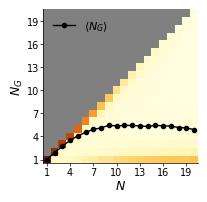

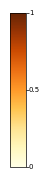

In [24]:
# heatmap
w = 2
h = 2
labelsize = 9
ticksize = 7

fig, ax = plt.subplots(figsize=(w,h))
x_edges = np.arange(N_vals[0] - 0.5, N_vals[-1] + 1.5)
y_edges = np.arange(1 - 0.5, max(N_vals) + 1.5)

im = ax.pcolormesh(x_edges, y_edges, probabilities_all_NG,
                   vmin=0, vmax=1, cmap='YlOrBr',antialiased=False,
                   linewidth=0)
# im = ax.imshow(probabilities_all_NG, origin='lower', extent=(N_vals[0]-0.5, N_vals[-1]+0.5, 0.5, max(N_vals)+0.5), vmin=0, vmax=1,cmap='YlOrBr')
ax.plot(N_vals, avg_subgroup_size, color='k', marker='.', linewidth=1, markersize=6, alpha=1, label=r'$\langle N_G \rangle$')
ticks = range(1,max(N_vals)+1)
ax.set_xlim(0.5,20.5)
ax.set_ylim(0.5,20.5)
ax.set_xticks(ticks[0::3])
ax.set_yticks(ticks[0::3])
ax.set_ylabel('$N_G$', fontsize=labelsize, labelpad=1)
ax.set_xlabel('$N$', fontsize=labelsize, labelpad=1)
ax.set_fc('grey')
ax.tick_params(axis='both', which='major', labelsize=ticksize, pad=1, width=0.5, length=2)
# turn off top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.legend(loc='upper left', bbox_to_anchor=(0,1), fontsize=8, frameon=False)
#ax.set_aspect('equal')
im.set_rasterized(True) 


# color bar on separate fig
w = 0.2
h = 2
fig, ax = plt.subplots(1,1, figsize=(w,h))
cbar = fig.colorbar(im, cax=ax)
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
#cbar.set_label('Transition probability', fontsize=7, labelpad=1)
cbar.set_ticks([0,0.5,1],labels=["0","0.5","1"])
# set tick padding
cbar.ax.yaxis.set_tick_params(pad=0.5)
cbar.outline.set_linewidth(0.5)

---------

# Simulations with mixed age groups

In [32]:
def run_mix_age_sims_and_analysis(
    microscopic_params=microscopic_params_full_dataset, 
    mix_age_idxs=[2,3], 
    arena_radius=150, 
    N_mix=8, 
    Tmax=600, 
    n_sims=100, 
    dt=0.01, 
    L=L
    ):

    #array with x,y,theta for each mixture
    sim_results_mix_ages = np.empty((n_sims,3,N_mix, np.ceil(Tmax/dt).astype(int)+1))
    i = mix_age_idxs[0]
    j = mix_age_idxs[1]

    v = np.concatenate([np.ones(int(N_mix/2))*microscopic_params[i,3],np.ones(int(N_mix/2))*microscopic_params[j,3]])
    s = np.concatenate((microscopic_params[i,0] * np.ones(int(N_mix/2)), microscopic_params[j,0] * np.ones(int(N_mix/2))))#s^-1, rate of diffusion
    eps = np.concatenate((microscopic_params[i,1]* np.ones(int(N_mix/2)),microscopic_params[j,1] * np.ones(int(N_mix/2)))) #variance of diffusion noise
    c = np.concatenate((microscopic_params[i,2] * np.ones(int(N_mix/2)),microscopic_params[j,2] * np.ones(int(N_mix/2)))) #s^-1, rate of copying 

    for kk in range(n_sims):
        sim = Simulate_Fish_School(
            N=N_mix,
            v=v,
            R=arena_radius,
            s = s,
            eps = eps,
            c=c,
            Tmax = Tmax,
            dt = dt,
            L = L,
            seed = kk
        )
        x,y,theta = sim.run_simulation()
        sim_results_mix_ages[kk,0,:,:] = x
        sim_results_mix_ages[kk,1,:,:] = y
        sim_results_mix_ages[kk,2,:,:] = theta
        
    print("Mix age simulations completed at", datetime.now().strftime('%H:%M:%S'))

    # sim results for homogenous age groups
    i = mix_age_idxs[0]
    N = int(N_mix/2)
    v = np.ones(N)*microscopic_params[i,3]
    s = np.ones(N)*microscopic_params[i,0] #s^-1, rate of diffusion
    eps = np.ones(N)*microscopic_params[i,1] #variance of diffusion noise
    c = np.ones(N)*microscopic_params[i,2] #s^-1, rate of copying 
    sim_results_young = np.empty((n_sims,3,N, np.ceil(Tmax/dt).astype(int)+1))
    for kk in range(n_sims):
        sim = Simulate_Fish_School(
            N=N,
            v=v,
            R=arena_radius,
            s=s,
            eps=eps,
            c=c,
            Tmax=Tmax,
            dt=dt,
            L=L,
            seed = kk
        )
        x,y,theta = sim.run_simulation()
        sim_results_young[kk,0,:,:] = x
        sim_results_young[kk,1,:,:] = y
        sim_results_young[kk,2,:,:] = theta

    j = mix_age_idxs[1]
    N = int(N_mix/2)
    v = np.ones(N)*microscopic_params[j,3]
    s = np.ones(N)*microscopic_params[j,0] #s^-1, rate of diffusion
    eps = np.ones(N)*microscopic_params[j,1] #variance of diffusion
    c = np.ones(N)*microscopic_params[j,2] #s^-1, rate of copying 
    sim_results_old = np.empty((n_sims,3,N, np.ceil(Tmax/dt).astype(int)+1))
    for kk in range(n_sims):
        sim = Simulate_Fish_School(
            N=N,
            v=v,
            R=arena_radius,
            s=s,
            eps=eps,
            c=c,
            Tmax=Tmax,
            dt=dt,
            L=L,
            seed = kk
        )
        x,y,theta = sim.run_simulation()
        sim_results_old[kk,0,:,:] = x
        sim_results_old[kk,1,:,:] = y
        sim_results_old[kk,2,:,:] = theta

    print("Single age simulations completed at", datetime.now().strftime('%H:%M:%S'))

    # analysis
    # find pairwise distance and alignmeng for fish in mixture and alone
    dist_young_mix = []
    dist_old_mix = []
    dist_young_alone = []
    dist_old_alone = []
    dist_across_ages = []

    alignment_young_mix = []
    alignment_old_mix = []
    alignment_young_alone = []
    alignment_old_alone = []
    alignment_across_ages = []

    ###### mixture
    x_young_mix = sim_results_mix_ages[:,0,0:int(N_mix/2),:]
    y_young_mix = sim_results_mix_ages[:,1,0:int(N_mix/2),:]
    theta_young_mix = sim_results_mix_ages[:,2,0:int(N_mix/2),:]
    x_old_mix = sim_results_mix_ages[:,0,int(N_mix/2):N_mix,:]
    y_old_mix = sim_results_mix_ages[:,1,int(N_mix/2):N_mix,:]
    theta_old_mix = sim_results_mix_ages[:,2,int(N_mix/2):N_mix,:]

    # pairwise distance & alignment for pairs of fish 
    # same age in mixture
    for i in range(N):
        for j in range(i+1,N):
            for kk in range(n_sims):
                alignment_young_mix.append(np.cos(theta_young_mix[kk,i,:]-theta_young_mix[kk,j,:]).mean())
                alignment_old_mix.append(np.cos(theta_old_mix[kk,i,:]-theta_old_mix[kk,j,:]).mean())
                dist_young_mix.append(np.mean(np.sqrt((x_young_mix[kk,i,:]-x_young_mix[kk,j,:])**2 + (y_young_mix[kk,i,:]-y_young_mix[kk,j,:])**2)))
                dist_old_mix.append(np.mean(np.sqrt((x_old_mix[kk,i,:]-x_old_mix[kk,j,:])**2 + (y_old_mix[kk,i,:]-y_old_mix[kk,j,:])**2)))
    # across ages in mixture
    for i in range(N):
        for j in range(N):
            for kk in range(n_sims):
                alignment_across_ages.append(np.cos(theta_young_mix[kk,i,:]-theta_old_mix[kk,j,:]).mean())
                dist_across_ages.append(np.mean(np.sqrt((x_young_mix[kk,i,:]-x_old_mix[kk,j,:])**2 + (y_young_mix[kk,i,:]-y_old_mix[kk,j,:])**2)))

    ###### alone
    x_young_alone = sim_results_young[:,0,:,:]
    y_young_alone = sim_results_young[:,1,:,:]
    theta_young_alone = sim_results_young[:,2,:,:]
    x_old_alone = sim_results_old[:,0,:,:]
    y_old_alone = sim_results_old[:,1,:,:]
    theta_old_alone = sim_results_old[:,2,:,:]

    # pairwise distance & alignment for pairs of fish 
    for i in range(N):
        for j in range(i+1,N):
            for kk in range(n_sims):
                alignment_young_alone.append(np.cos(theta_young_alone[kk,i,:]-theta_young_alone[kk,j,:]).mean())
                alignment_old_alone.append(np.cos(theta_old_alone[kk,i,:]-theta_old_alone[kk,j,:]).mean())
                dist_young_alone.append(np.mean(np.sqrt((x_young_alone[kk,i,:]-x_young_alone[kk,j,:])**2 + (y_young_alone[kk,i,:]-y_young_alone[kk,j,:])**2)))
                dist_old_alone.append(np.mean(np.sqrt((x_old_alone[kk,i,:]-x_old_alone[kk,j,:])**2 + (y_old_alone[kk,i,:]-y_old_alone[kk,j,:])**2)))

    
    # convert to arrays
    alignment_young_mix = np.array(alignment_young_mix)
    alignment_old_mix = np.array(alignment_old_mix)
    alignment_young_alone = np.array(alignment_young_alone)
    alignment_old_alone = np.array(alignment_old_alone)
    alignment_across_ages = np.array(alignment_across_ages)
    dist_young_mix = np.array(dist_young_mix)
    dist_old_mix = np.array(dist_old_mix)
    dist_young_alone = np.array(dist_young_alone)
    dist_old_alone = np.array(dist_old_alone)
    dist_across_ages = np.array(dist_across_ages)

    # save to dictionary
    analysis_results = {
        'alignment_young_mix': alignment_young_mix,
        'alignment_old_mix': alignment_old_mix,
        'alignment_young_alone': alignment_young_alone,
        'alignment_old_alone': alignment_old_alone,
        'alignment_across_ages': alignment_across_ages,
        'dist_young_mix': dist_young_mix,
        'dist_old_mix': dist_old_mix,
        'dist_young_alone': dist_young_alone,
        'dist_old_alone': dist_old_alone,
        'dist_across_ages': dist_across_ages
    }

    sim_results = {
        'mix_ages': sim_results_mix_ages,
        'young_alone': sim_results_young,
        'old_alone': sim_results_old
    }

    return analysis_results, sim_results

In [30]:
n_sims = 100
mix_age_idxs = [2,3] # 6 and 8 weeks
N_mix = 8
Tmax = 600
dt = 0.01
L=50
N = int(N_mix)/2

In [33]:
results_path = Path('../../Results/mixed_ages_analysis_results.pkl')

if results_path.is_file():
    with open(results_path,'rb') as f:
        results = pickle.load(f)
    mixed_ages_analysis_results = results['analysis_results']
    mixed_ages_sims = results['sims']
else:
    mixed_ages_analysis_results, mixed_ages_sims = run_mix_age_sims_and_analysis(
        mix_age_idxs=mix_age_idxs,
        N_mix=N_mix, 
        Tmax=Tmax, 
        n_sims=n_sims,
        dt=dt, 
        L=L, 
    )
    # save to file
    with open(results_path, 'wb') as f:
        pickle.dump({'analysis_results' : mixed_ages_analysis_results,
                    'sims' : mixed_ages_sims}, f)


Mix age simulations completed at 14:47:51
Single age simulations completed at 14:52:13


In [34]:
alignment_young_mix = mixed_ages_analysis_results['alignment_young_mix']
alignment_old_mix = mixed_ages_analysis_results['alignment_old_mix']
alignment_young_alone = mixed_ages_analysis_results['alignment_young_alone']
alignment_old_alone = mixed_ages_analysis_results['alignment_old_alone']
alignment_across_ages = mixed_ages_analysis_results['alignment_across_ages']
dist_young_mix = mixed_ages_analysis_results['dist_young_mix']
dist_old_mix = mixed_ages_analysis_results['dist_old_mix']
dist_young_alone = mixed_ages_analysis_results['dist_young_alone']
dist_old_alone = mixed_ages_analysis_results['dist_old_alone']
dist_across_ages = mixed_ages_analysis_results['dist_across_ages']
sim_results_mix_ages = mixed_ages_sims['mix_ages']
sim_results_young = mixed_ages_sims['young_alone']
sim_results_old = mixed_ages_sims['old_alone']


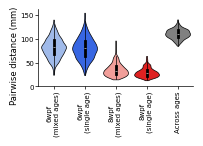

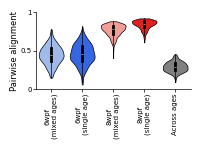

In [35]:
# violin plots
import seaborn as sns

w = 2
h = 1
colors = ['#94b6f5','#1a59ff','#ff918b','#fe0101', "#808080"]
labels = [f'{fish_ages[mix_age_idxs[0]]}wpf\n(mixed ages)', f'{fish_ages[mix_age_idxs[0]]}wpf\n(single age)', f'{fish_ages[mix_age_idxs[1]]}wpf\n(mixed ages)', f'{fish_ages[mix_age_idxs[1]]}wpf\n(single age)', 'Across ages']
ticksize = 5
labelsize = 6

sns.set_palette(sns.color_palette(colors))

# pairwise distance
fig, ax = plt.subplots(1,1, figsize=(w,h))
rng = np.random.default_rng(seed=42)  # For reproducibility
size = len(dist_young_mix)
data = np.column_stack([dist_young_mix, dist_young_alone, dist_old_mix, dist_old_alone, rng.choice(dist_across_ages,size=size, replace=False)])
sns.violinplot(data=data,ax=ax,width=0.8,linewidth=0.5,linecolor='k',inner='box',inner_kws=dict(box_width=2,whis_width=0.5),cut=0)
ax.set_xticks([0,1,2,3,4],labels,rotation=90, fontsize=ticksize, ha='center', ma='center')
#ax.set_ylim([0,75])'
ax.set_yticks([0,50,100,150],["0","50","100","150"], fontsize=ticksize)
ylabel = ax.set_ylabel("Pairwise distance (mm)", fontsize=labelsize, labelpad=1)
ylabel.set_position((0,0.4))
# turn off top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# set width of left and bottom spines
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', pad=1, width=0.5, length=2)

# pairwise alignment
fig, ax = plt.subplots(1,1, figsize=(w,h))
rng = np.random.default_rng(seed=42)  # For reproducibility
size = len(alignment_young_mix)
data = np.column_stack([alignment_young_mix, alignment_young_alone, alignment_old_mix, alignment_old_alone, rng.choice(alignment_across_ages,size=size, replace=False)])
sns.violinplot(data=data,ax=ax,width=0.8,linewidth=0.5,linecolor='k',inner='box',inner_kws=dict(box_width=2,whis_width=0.5),cut=0)
ax.set_xticks([0,1,2,3,4],labels,rotation=90, fontsize=ticksize, ha='center', ma='center')
#ax.set_ylim([0,75])'
ax.set_yticks([0,0.5,1],["0","0.5","1"], fontsize=ticksize)
ylabel = ax.set_ylabel("Pairwise alignment", fontsize=labelsize, labelpad=1)
# ylabel.set_position((0,0.4))
# turn off top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# set width of left and bottom spines
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', pad=1, width=0.5, length=2)

In [36]:
# t-tests
from scipy.stats import ttest_ind

# distance
print("Pairwise distance t-tests:")
stat, p = ttest_ind(dist_young_mix, dist_young_alone)
print(f"Young mixed vs alone: stat={stat:.3f}, p={p:.3f}")
stat, p = ttest_ind(dist_old_mix, dist_old_alone)
print(f"Old mixed vs alone: stat={stat:.3f}, p={p:.3f}")

# alignment
print("\nPairwise alignment t-tests:")
stat, p = ttest_ind(alignment_young_mix, alignment_young_alone)
print(f"Young mixed vs alone: stat={stat:.3f}, p={p:.3f}")
stat, p = ttest_ind(alignment_old_mix, alignment_old_alone)
print(f"Old mixed vs alone: stat={stat:.3f}, p={p:.3f}")

Pairwise distance t-tests:
Young mixed vs alone: stat=0.968, p=0.333
Old mixed vs alone: stat=8.276, p=0.000

Pairwise alignment t-tests:
Young mixed vs alone: stat=-1.641, p=0.101
Old mixed vs alone: stat=-18.749, p=0.000
